# Exploring Chemical Space
Explore some clustering and visualisation models and compare them for two different datasets:
- A subset of ChEMBL small molecule entries with a molecular weight between 200 and 500. Since the entire set of ChEMBL entries is quite substantial, 10k entries were selected by random sampling (`chembl_200-500_10k`)
- The result of the PubChem search for "antibiotics" (`pubchem_antibiotics`).

Note: The ChEMBL dataset may still take quite some processing time - depending on your PC. You can do a random sampling of e.g. 3k entries in order to reduce the computational effort.

Tasks:
1) Load and inspect the two datasets `ChEMBL_200-500_10k.csv`. Note that they are fundamentally different.
2) Perform basic data cleaning and be mindful of which data to dismiss (if any). Hint: Think about standardising column names (at least for the relevant ones)
3) Make sure that the SMILES strings are valid - implement a function to clean up the SMILES returning (in a new column or Series) the canonical SMILES if the input is valid, and return `None` if the SMILES in the original data is not valid (). Hint: The `Normalizer` in  rdkit might be quite useful (https://www.rdkit.org/docs/cppapi/classRDKit_1_1MolStandardize_1_1Normalizer.html)
4) Calculate Morgan Fingerprints (radius 2, 2048 bit) from the SMILES strings via mol objects. Make sure not to use the outdated version. You can use either the dataframe, numpy arrays or simple lists for the fingerprints.
5) Run different clustering techniques, e.g. snippets provided for Butina and HDBSCAN. You can also try the scikit-learn models kmeans or dbscan.
6) Use the fingerprints to run UMAP and TSNE dimensionality reductions (snippets provided).
7) Plot the data in scatterplots, using the cluster labels as colour map.
8) Adjust some parameters of the clustering models and apply filters if needed (e.g. only visualise clusters of a size larger than 10) to reach some satisfactory result
9) Visualise a representative molecule (e.g. centroids or centers of clusters, or random :) ) of the three largest clusters for both methods using rdkit
10) Respond to the discussion points


Import dependencies and datasets

In [2]:
# complete imports if needed for your solution
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem.MolStandardize.rdMolStandardize import Normalizer
from rdkit.Chem import rdFingerprintGenerator
from rdkit import DataStructs
from rdkit.ML.Cluster import Butina
from rdkit.Chem import Draw

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
import hdbscan
import umap
from sklearn.manifold import TSNE

c:\Users\shimo\DSA104\DSA104\.venv\Lib\site-packages\hdbscan\robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [23]:
chembl_path = "ChEMBL_200-500_10k.csv"
pubchem_path = "pubchem_antibiotics.csv"

In [24]:
chembl_df = pd.read_csv(chembl_path)
pubchem_df = pd.read_csv(pubchem_path)

print("ChEMBL shape:", chembl_df.shape)
print("PubChem shape:", pubchem_df.shape)

display(chembl_df.head())
display(pubchem_df.head())

print("ChEMBL columns:")
print(chembl_df.columns.tolist())

print("\nPubChem columns:")
print(pubchem_df.columns.tolist())

ChEMBL shape: (10000, 29)
PubChem shape: (2358, 38)


,ChEMBL ID,Name,Synonyms,Type,Max Phase,Molecular Weight,Targets,Bioactivities,AlogP,Polar Surface Area,...,Heavy Atoms,Np Likeness Score,Molecular Formula,SMILES,Inchi Key,Inchi,Withdrawn Flag,Orphan,Records Key,Records Name
0,CHEMBL50524,NaN,NaN,Small molecule,NaN,361.47,2.0,2.0,1.96,84.66,...,25.0,-0.79,C18H23N3O3S,Nc1c(NC/C=C\COc2csc(CN3CCCCC3)c2)c(=O)c1=O,ZXLCEKMBIFPOSF-DJWKRKHSSA-N,InChI=1S/C18H23N3O3S/c19-15-16(18(23)17(15)22)...,False,-1,['12a'],['3-Amino-4-[(Z)-4-(5-piperidin-1-ylmethyl-thi...
1,CHEMBL1719619,NaN,NaN,Small molecule,NaN,339.35,4.0,4.0,2.33,110.62,...,25.0,-0.90,C18H17N3O4,COc1ccc(OC)c(C2C(C#N)=C(N)Oc3cc(C)nc(O)c32)c1,ATRZEYKVGNFNIL-UHFFFAOYSA-N,InChI=1S/C18H17N3O4/c1-9-6-14-16(18(22)21-9)15...,False,-1,"['SID859991', 'SID87345386']","['SID859991', 'SID87345386']"
2,CHEMBL1989505,NaN,NaN,Small molecule,NaN,417.54,2.0,2.0,6.02,92.93,...,30.0,-1.12,C23H23N5OS,Cc1ccc(NC(=O)Nc2ccc(-c3c(C(C)C)sc4ncnc(N)c34)c...,OCRAIYGHHHMVJB-UHFFFAOYSA-N,InChI=1S/C23H23N5OS/c1-13(2)20-18(19-21(24)25-...,False,-1,['SID103904394'],['SID103904394']
3,CHEMBL1673052,NaN,NaN,Small molecule,NaN,487.61,3.0,9.0,4.12,77.07,...,36.0,-1.28,C27H33N7O2,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc2c(n1)N(C(C)C)c1c...,YYTFTZONXCQXLW-UHFFFAOYSA-N,InChI=1S/C27H33N7O2/c1-18(2)34-22-9-7-6-8-20(2...,False,-1,"['24', 'XMD10-78', 'Compound 18']",['11-isopropyl-2-((2-methoxy-4-(4-methylpipera...
4,CHEMBL3084770,NaN,NaN,Small molecule,NaN,426.56,1.0,1.0,3.58,70.84,...,31.0,-0.62,C24H34N4O3,CC[C@H]1COC[C@H](C)N1c1nc2c(C(=O)N[C@@H]3C[C@H...,UIKMHGOYAXJLIA-VPAKFMSCSA-N,InChI=1S/C24H34N4O3/c1-4-17-14-30-13-15(2)28(1...,False,-1,['35'],"['endo-2-((3S,5S)-3-ethyl-5-methylmorpholino)-..."


,Compound_CID,Name,Synonyms,Molecular_Formula,InChI,Smiles,InChIKey,IUPAC_Name,MeSH_Headings,Annotation_Content,...,Defined_Atom_Stereo_Count,Undefined_Atom_Stereo_Count,Total_Bond_Stereo_Count,Defined_Bond_Stereo_Count,Undefined_Bond_Stereo_Count,Linked_PubChem_Literature_Count,Linked_PubChem_Patent_Count,Linked_PubChem_Patent_Family_Count,Annotation_Type_Count,Create_Date
0,16131155,Antibiotic A 47934,A-47934 Antibiotic|Antibiotic A 47934|RefChem:...,C58H44Cl3N7O21S,InChI=1S/C58H44Cl3N7O21S/c59-31-7-20-1-4-36(31...,C1[C@@H]2C(=O)N[C@@H](C3=CC(=CC(=C3)OC4=C(C=CC...,HRGFAEUWEMDRRZ-QLRHZSCISA-N,"(1S,2R,19R,22R,34S,37R,40R,52S)-22-amino-5,15,...",antibiotic A 47934,Classification|Literature|Patents|Taxonomy,...,8,0,0,0,0,17,60,13,4,20070703
1,6439108,Antibiotic S 632-B1,Antibiotic S 632-B1|121995-32-2|S632-B1|S632-B...,C17H25NO5,InChI=1S/C17H25NO5/c1-9(4-10(2)17-11(3)23-17)1...,CC1C(O1)/C(=C\C(C)C(=O)CC(CC2CC(=O)NC(=O)C2)O)/C,JEIOGENOOQCFDS-WMZJFQQLSA-N,4-[(Z)-2-hydroxy-5-methyl-7-(3-methyloxiran-2-...,antibiotic S 632-B1,Classification|Literature|Toxicity,...,0,4,1,1,0,3,0,0,3,20060428
2,9690107,Antibiotic FK 089,FK-089 antibiotic|Antibiotic FK 089|86070-74-8...,C14H12N4O7S2,InChI=1S/C14H12N4O7S2/c19-8(20)3-25-17-9(6-4-2...,C1C=C(N2[C@H](S1)[C@@H](C2=O)NC(=O)/C(=N\OCC(=...,YVVLVHFJBQEWHH-NSHRYQRRSA-N,"(6R,7R)-7-[[(2Z)-2-(carboxymethoxyimino)-2-(1,...",antibiotic FK 089,Biological Test Results|Classification|Literat...,...,2,0,1,1,0,2,5,1,4,20061024
3,125607,Antibiotic A447 C,Antibiotic A447 C|95599-38-5|Antibiotic A447-C...,C60H88N2O20,InChI=1S/C60H88N2O20/c1-12-60(70)26-41(79-46-2...,CCC1(CC(C2=C(C1OC3CC(C(C(O3)C)OC4CCC(C(O4)C)OC...,JCVKGZNZMVGUIP-UHFFFAOYSA-N,"7,10-bis[[4-(dimethylamino)-5-[5-(5-hydroxy-6-...",antibiotic A447 C,Classification|Literature,...,0,23,0,0,0,1,0,0,2,20050808
4,5487319,DOB-41 antibiotic,Dob-41 antibiotic|Antibiotic dob 41|115666-98-...,C19H18N2O6,InChI=1S/C19H18N2O6/c1-10(27-19(25)15(9-22)26-...,C[C@H](C1=C2C(=CC=C1)N=C3C(=N2)C=CC=C3C(=O)O)O...,OSEDIRANPWGFRX-MEBBXXQBSA-N,6-[(1R)-1-[(2R)-3-hydroxy-2-methoxypropanoyl]o...,DOB-41 antibiotic,Classification|Literature|Patents,...,2,0,0,0,0,1,5,1,3,20050808


ChEMBL columns:
['ChEMBL ID', 'Name', 'Synonyms', 'Type', 'Max Phase', 'Molecular Weight', 'Targets', 'Bioactivities', 'AlogP', 'Polar Surface Area', 'HBA', 'HBD', '#RO5 Violations', '#Rotatable Bonds', 'Passes Ro3', 'QED Weighted', 'Aromatic Rings', 'Structure Type', 'Inorganic Flag', 'Heavy Atoms', 'Np Likeness Score', 'Molecular Formula', 'SMILES', 'Inchi Key', 'Inchi', 'Withdrawn Flag', 'Orphan', 'Records Key', 'Records Name']

PubChem columns:
['Compound_CID', 'Name', 'Synonyms', 'Molecular_Formula', 'InChI', 'Smiles', 'InChIKey', 'IUPAC_Name', 'MeSH_Headings', 'Annotation_Content', 'Linked_BioAssays', 'Data_Source', 'Data_Source_Category', 'Tagged_by_PubChem', 'Molecular_Weight', 'Polar_Area', 'Complexity', 'XLogP', 'Heavy_Atom_Count', 'H-Bond_Donor_Count', 'H-Bond_Acceptor_Count', 'Rotatable_Bond_Count', 'Exact_Mass', 'Monoisotopic_Mass', 'Charge', 'Covalent_Unit_Count', 'Isotopic_Atom_Count', 'Total_Atom_Stereo_Count', 'Defined_Atom_Stereo_Count', 'Undefined_Atom_Stereo_Count',

Data cleaning

In [25]:
def standardize_chembl(df):
    df = df.copy()
    df.columns = [c.strip().lower() for c in df.columns]

    rename_map = {
        "chembl_id": "id",
        "name": "name",
        "smiles": "smiles_raw"
    }
    df = df.rename(columns=rename_map)

    keep_cols = [c for c in ["id", "name", "smiles_raw", "molecular_weight", "molecular_formula"] if c in df.columns]
    df = df[keep_cols].copy()
    df["dataset"] = "ChEMBL"
    return df


def standardize_pubchem(df):
    df = df.copy()
    df.columns = [c.strip().lower() for c in df.columns]

    rename_map = {
        "compound_cid": "id",
        "name": "name",
        "smiles": "smiles_raw"
    }
    df = df.rename(columns=rename_map)

    keep_cols = [c for c in ["id", "name", "smiles_raw", "molecular_weight", "molecular_formula", "iupac_name"] if c in df.columns]
    df = df[keep_cols].copy()
    df["dataset"] = "PubChem_antibiotics"
    return df


chembl_std = standardize_chembl(chembl_df)
pubchem_std = standardize_pubchem(pubchem_df)

print(chembl_std.head())
print(pubchem_std.head())

  name                                         smiles_raw dataset
0  NaN         Nc1c(NC/C=C\COc2csc(CN3CCCCC3)c2)c(=O)c1=O  ChEMBL
1  NaN      COc1ccc(OC)c(C2C(C#N)=C(N)Oc3cc(C)nc(O)c32)c1  ChEMBL
2  NaN  Cc1ccc(NC(=O)Nc2ccc(-c3c(C(C)C)sc4ncnc(N)c34)c...  ChEMBL
3  NaN  COc1cc(N2CCN(C)CC2)ccc1Nc1ncc2c(n1)N(C(C)C)c1c...  ChEMBL
4  NaN  CC[C@H]1COC[C@H](C)N1c1nc2c(C(=O)N[C@@H]3C[C@H...  ChEMBL
         id                 name  \
0  16131155   Antibiotic A 47934   
1   6439108  Antibiotic S 632-B1   
2   9690107    Antibiotic FK 089   
3    125607    Antibiotic A447 C   
4   5487319    DOB-41 antibiotic   

                                          smiles_raw  molecular_weight  \
0  C1[C@@H]2C(=O)N[C@@H](C3=CC(=CC(=C3)OC4=C(C=CC...            1313.4   
1   CC1C(O1)/C(=C\C(C)C(=O)CC(CC2CC(=O)NC(=O)C2)O)/C             323.4   
2  C1C=C(N2[C@H](S1)[C@@H](C2=O)NC(=O)/C(=N\OCC(=...             412.4   
3  CCC1(CC(C2=C(C1OC3CC(C(C(O3)C)OC4CCC(C(O4)C)OC...            1157.3   
4  C[C@H](C1=C2C(

Calculate Morgan Fingerprints (`GetMorganGenerator`). You can experiment with other fingerprints (`GetRDKitFPGenerator`) as well and see how they impact the clusters.

In [26]:
normalizer = Normalizer()

def clean_smiles(smiles):
    if pd.isna(smiles):
        return None
    smiles = str(smiles).strip()
    if smiles == "":
        return None

    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None

        # normalize molecule
        mol = normalizer.normalize(mol)

        # sanitize again just in case
        Chem.SanitizeMol(mol)

        # canonical smiles
        can_smi = Chem.MolToSmiles(mol, canonical=True)
        return can_smi
    except:
        return None

[22:49:10] Initializing Normalizer


In [27]:
chembl_std["smiles_clean"] = chembl_std["smiles_raw"].apply(clean_smiles)
pubchem_std["smiles_clean"] = pubchem_std["smiles_raw"].apply(clean_smiles)

print("ChEMBL valid SMILES:", chembl_std["smiles_clean"].notna().sum(), "/", len(chembl_std))
print("PubChem valid SMILES:", pubchem_std["smiles_clean"].notna().sum(), "/", len(pubchem_std))

[22:49:34] Running Normalizer
[22:49:34] Running Normalizer
[22:49:34] Running Normalizer
[22:49:34] Running Normalizer
[22:49:34] Running Normalizer
[22:49:34] Running Normalizer
[22:49:34] Running Normalizer
[22:49:34] Running Normalizer
[22:49:34] Running Normalizer
[22:49:34] Running Normalizer
[22:49:34] Running Normalizer
[22:49:34] Running Normalizer
[22:49:34] Running Normalizer
[22:49:34] Running Normalizer
[22:49:34] Running Normalizer
[22:49:34] Running Normalizer
[22:49:34] Running Normalizer
[22:49:34] Running Normalizer
[22:49:34] Running Normalizer
[22:49:34] Running Normalizer
[22:49:34] Running Normalizer
[22:49:34] Running Normalizer
[22:49:34] Running Normalizer
[22:49:34] Running Normalizer
[22:49:34] Running Normalizer
[22:49:34] Running Normalizer
[22:49:34] Running Normalizer
[22:49:34] Running Normalizer
[22:49:34] Running Normalizer
[22:49:34] Running Normalizer
[22:49:34] Running Normalizer
[22:49:34] Running Normalizer
[22:49:34] Running Normalizer
[22:49:34]

ChEMBL valid SMILES: 9993 / 10000
PubChem valid SMILES: 2358 / 2358


[22:49:44] Running Normalizer
[22:49:44] Running Normalizer
[22:49:44] Running Normalizer
[22:49:44] Running Normalizer
[22:49:44] Running Normalizer
[22:49:44] Running Normalizer
[22:49:44] Running Normalizer
[22:49:44] Running Normalizer
[22:49:44] Running Normalizer
[22:49:44] Running Normalizer
[22:49:44] Running Normalizer
[22:49:44] Running Normalizer
[22:49:44] Running Normalizer
[22:49:44] Running Normalizer
[22:49:44] Running Normalizer
[22:49:44] Running Normalizer
[22:49:44] Running Normalizer
[22:49:44] Running Normalizer
[22:49:44] Running Normalizer
[22:49:44] Running Normalizer
[22:49:44] Running Normalizer
[22:49:44] Running Normalizer
[22:49:44] Running Normalizer
[22:49:44] Running Normalizer
[22:49:44] Running Normalizer
[22:49:44] Running Normalizer
[22:49:44] Running Normalizer
[22:49:44] Running Normalizer
[22:49:44] Running Normalizer
[22:49:44] Running Normalizer
[22:49:44] Running Normalizer
[22:49:44] Running Normalizer
[22:49:44] Running Normalizer
[22:49:44]

In [28]:
def finalize_cleaning(df):
    df = df.copy()

    # drop invalid smiles
    df = df[df["smiles_clean"].notna()].copy()

    # remove duplicate canonical smiles
    df = df.drop_duplicates(subset="smiles_clean").reset_index(drop=True)

    return df

chembl_clean = finalize_cleaning(chembl_std)
pubchem_clean = finalize_cleaning(pubchem_std)

print("ChEMBL after cleaning:", chembl_clean.shape)
print("PubChem after cleaning:", pubchem_clean.shape)

ChEMBL after cleaning: (9993, 4)
PubChem after cleaning: (2356, 8)


In [29]:
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def smiles_to_mol(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol
    except:
        return None

def add_mols_and_fps(df):
    df = df.copy()
    df["mol"] = df["smiles_clean"].apply(smiles_to_mol)
    df = df[df["mol"].notna()].copy()

    df["fp"] = df["mol"].apply(lambda mol: morgan_gen.GetFingerprint(mol))
    return df.reset_index(drop=True)

chembl_fp = add_mols_and_fps(chembl_clean)
pubchem_fp = add_mols_and_fps(pubchem_clean)

print("ChEMBL fingerprints:", chembl_fp.shape)
print("PubChem fingerprints:", pubchem_fp.shape)

[22:51:49] WARNING: not removing hydrogen atom without neighbors
[22:51:49] WARNING: not removing hydrogen atom without neighbors
[22:51:49] WARNING: not removing hydrogen atom without neighbors
[22:51:49] WARNING: not removing hydrogen atom without neighbors
[22:51:49] WARNING: not removing hydrogen atom without neighbors
[22:51:49] WARNING: not removing hydrogen atom without neighbors
[22:51:49] WARNING: not removing hydrogen atom without neighbors


ChEMBL fingerprints: (9993, 6)
PubChem fingerprints: (2356, 10)


In [30]:
print("ChEMBL null mols:", chembl_fp["mol"].isna().sum())
print("PubChem null mols:", pubchem_fp["mol"].isna().sum())

print("ChEMBL null fps:", chembl_fp["fp"].isna().sum())
print("PubChem null fps:", pubchem_fp["fp"].isna().sum())

ChEMBL null mols: 0
PubChem null mols: 0
ChEMBL null fps: 0
PubChem null fps: 0


In [31]:
def fps_to_numpy(fp_list, n_bits=2048):
    X = np.zeros((len(fp_list), n_bits), dtype=np.int8)
    for i, fp in enumerate(fp_list):
        DataStructs.ConvertToNumpyArray(fp, X[i])
    return X

chembl_fp_list = chembl_fp["fp"].tolist()
pubchem_fp_list = pubchem_fp["fp"].tolist()

X_chembl = fps_to_numpy(chembl_fp_list)
X_pubchem = fps_to_numpy(pubchem_fp_list)

print(X_chembl.shape, X_pubchem.shape)

(9993, 2048) (2356, 2048)


Butina Clustering: Investigate later how different cutoffs for the similarity affect the clusters.

In [33]:
def butina_clustering(fp_list, cutoff=0.6, min_cluster_size=10):
    dists = []
    nfps = len(fp_list)

    for i in range(1, nfps):
        similarities = DataStructs.BulkTanimotoSimilarity(fp_list[i], fp_list[:i])
        dists.extend([1 - x for x in similarities])

    clusters = Butina.ClusterData(
        dists,
        nfps,
        cutoff,
        isDistData=True
    )

    # assign labels
    labels = np.full(nfps, -1, dtype=int)

    filtered_clusters = [c for c in clusters if len(c) >= min_cluster_size]

    for cluster_id, cluster in enumerate(filtered_clusters):
        for idx in cluster:
            labels[idx] = cluster_id

    sizes = [len(c) for c in filtered_clusters]

    stats = {
        "n_total_clusters": len(clusters),
        "n_filtered_clusters": len(filtered_clusters),
        "mean_cluster_size": np.mean(sizes) if sizes else 0,
        "max_cluster_size": np.max(sizes) if sizes else 0,
        "n_noise": np.sum(labels == -1)
    }

    return labels, clusters, filtered_clusters, stats

In [35]:
butina_labels_chembl, butina_clusters_chembl, butina_filtered_chembl, butina_stats_chembl = butina_clustering(
    chembl_fp_list, cutoff=0.6, min_cluster_size=10
)

butina_labels_pubchem, butina_clusters_pubchem, butina_filtered_pubchem, butina_stats_pubchem = butina_clustering(
    pubchem_fp_list, cutoff=0.5, min_cluster_size=10
)

print("ChEMBL Butina stats:", butina_stats_chembl)
print("PubChem Butina stats:", butina_stats_pubchem)

ChEMBL Butina stats: {'n_total_clusters': 6824, 'n_filtered_clusters': 31, 'mean_cluster_size': np.float64(14.483870967741936), 'max_cluster_size': np.int64(30), 'n_noise': np.int64(9544)}
PubChem Butina stats: {'n_total_clusters': 673, 'n_filtered_clusters': 47, 'mean_cluster_size': np.float64(24.02127659574468), 'max_cluster_size': np.int64(79), 'n_noise': np.int64(1227)}


HDBSCAN Clustering: Inspect how `min_cluster_size` and `min_samples` affect the clusters later on. This might depend quite a lot on the dataset (try 15 and 5 for the PubChem data, <10 and <5 for the ChEMBL)

In [36]:
def run_hdbscan(X, min_cluster_size=10, min_samples=2, metric="euclidean"):
    model = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric=metric
    )
    labels = model.fit_predict(X)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    stats = {
        "n_clusters": n_clusters,
        "n_noise": int(n_noise)
    }

    return labels, model, stats

In [37]:
hdb_labels_chembl, hdb_model_chembl, hdb_stats_chembl = run_hdbscan(
    X_chembl, min_cluster_size=8, min_samples=2, metric="euclidean"
)

hdb_labels_pubchem, hdb_model_pubchem, hdb_stats_pubchem = run_hdbscan(
    X_pubchem, min_cluster_size=15, min_samples=5, metric="euclidean"
)

print("ChEMBL HDBSCAN:", hdb_stats_chembl)
print("PubChem HDBSCAN:", hdb_stats_pubchem)

ChEMBL HDBSCAN: {'n_clusters': 3, 'n_noise': 1311}
PubChem HDBSCAN: {'n_clusters': 31, 'n_noise': 1312}


Embeddings: TSNE and UMAP

In [39]:
def run_umap(X, n_neighbors=25, min_dist=0.2, metric="jaccard", random_state=42):
    model = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric=metric,
        random_state=random_state
    )
    emb = model.fit_transform(X)
    return emb, model

In [40]:
def run_tsne(X, perplexity=30, random_state=42):
    model = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate="auto",
        init="pca",
        random_state=random_state
    )
    emb = model.fit_transform(X)
    return emb, model

In [62]:
umap_chembl, _ = run_umap(X_chembl, n_neighbors=25, min_dist=0.2, metric="jaccard")


umap_pubchem, _ = run_umap(X_pubchem, n_neighbors=25, min_dist=0.2, metric="jaccard")


c:\Users\shimo\DSA104\DSA104\.venv\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
c:\Users\shimo\DSA104\DSA104\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\shimo\DSA104\DSA104\.venv\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
c:\Users\shimo\DSA104\DSA104\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [61]:
tsne_chembl, _ = run_tsne(X_chembl, perplexity=30)
tsne_pubchem, _ = run_tsne(X_pubchem, perplexity=30)

Visualise the two clustering methods in the two embeddings (e.g. as subplot). Make sure to label the axes properly.

In [57]:


def plot_one(ax, embedding, labels, title, xlab, ylab):
    labels = np.array(labels)

    sc = ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=labels,
        cmap="tab20",
        s=10,
        alpha=0.8
    )

    ax.set_title(title)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)

    return sc


def plot_clustering_visualization(dataset_name, umap_embedding, tsne_embedding,
                                  butina_labels, hdb_labels):
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    # Row 1: Butina
    plot_one(
        axes[0, 0],
        umap_embedding,
        butina_labels,
        f"{dataset_name} - Butina on UMAP",
        "UMAP 1",
        "UMAP 2"
    )

    plot_one(
        axes[0, 1],
        tsne_embedding,
        butina_labels,
        f"{dataset_name} - Butina on t-SNE",
        "t-SNE 1",
        "t-SNE 2"
    )

    # Row 2: HDBSCAN
    plot_one(
        axes[1, 0],
        umap_embedding,
        hdb_labels,
        f"{dataset_name} - HDBSCAN on UMAP",
        "UMAP 1",
        "UMAP 2"
    )

    plot_one(
        axes[1, 1],
        tsne_embedding,
        hdb_labels,
        f"{dataset_name} - HDBSCAN on t-SNE",
        "t-SNE 1",
        "t-SNE 2"
    )

    plt.tight_layout()
    plt.show()

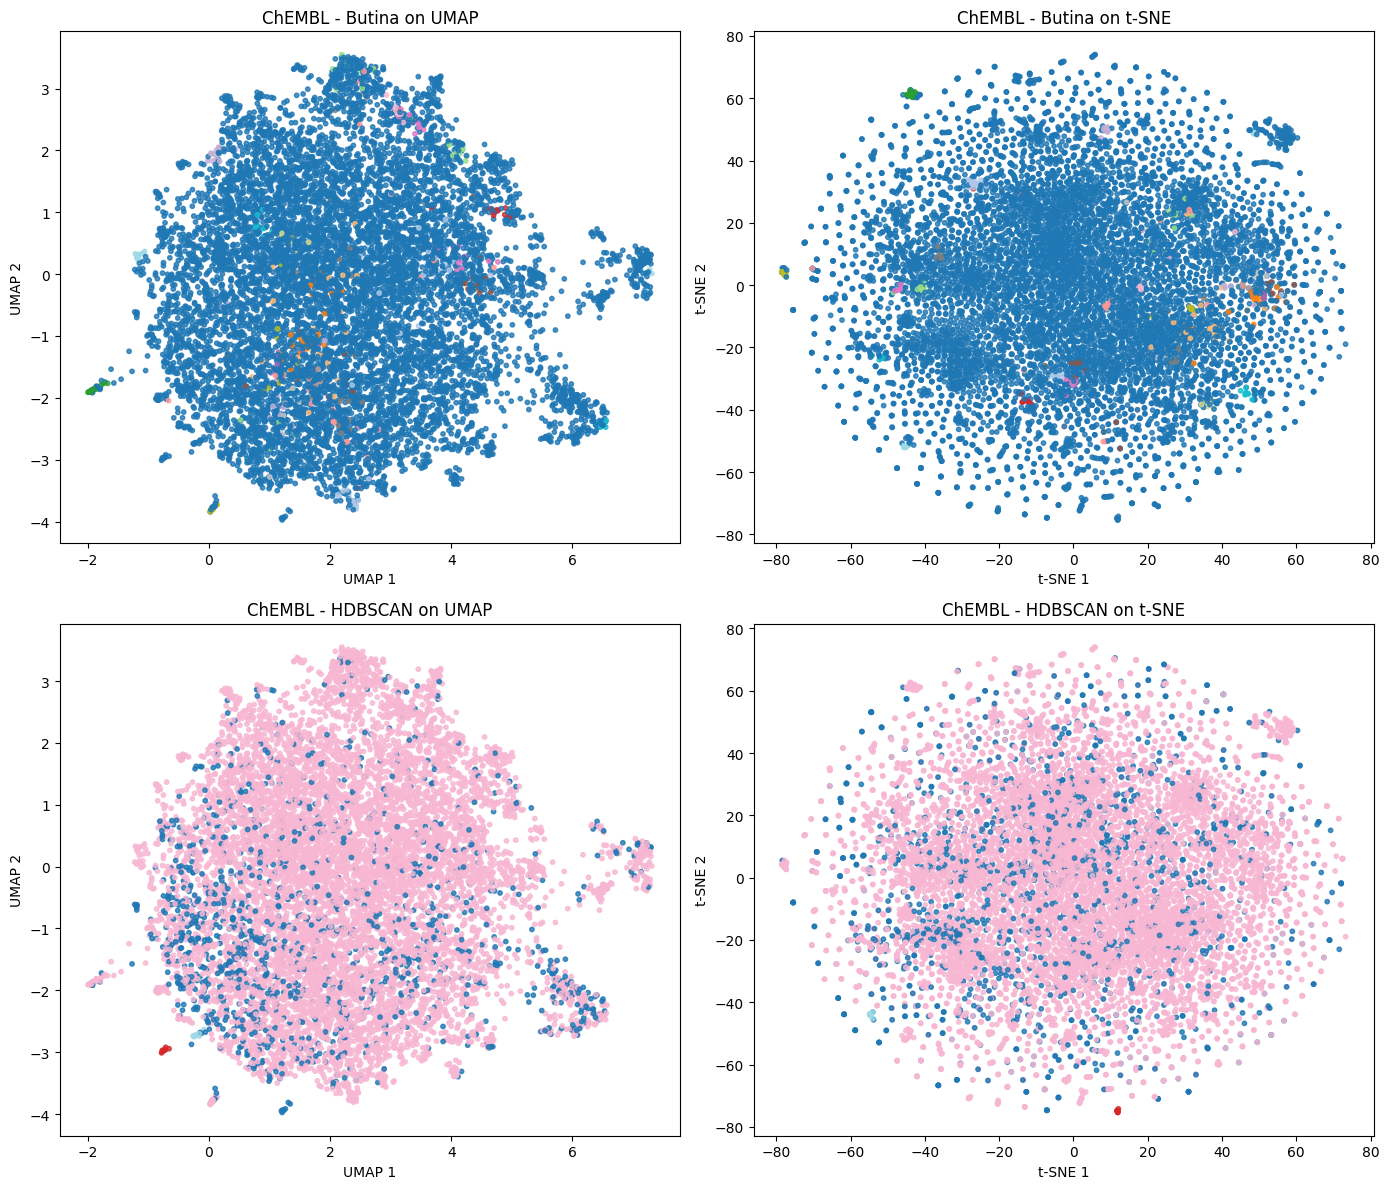

In [ ]:
plot_clustering_visualization(
    dataset_name="ChEMBL",
    umap_embedding=umap_chembl,
    butina_labels=butina_labels_chembl,
    hdb_labels=hdb_labels_chembl
)

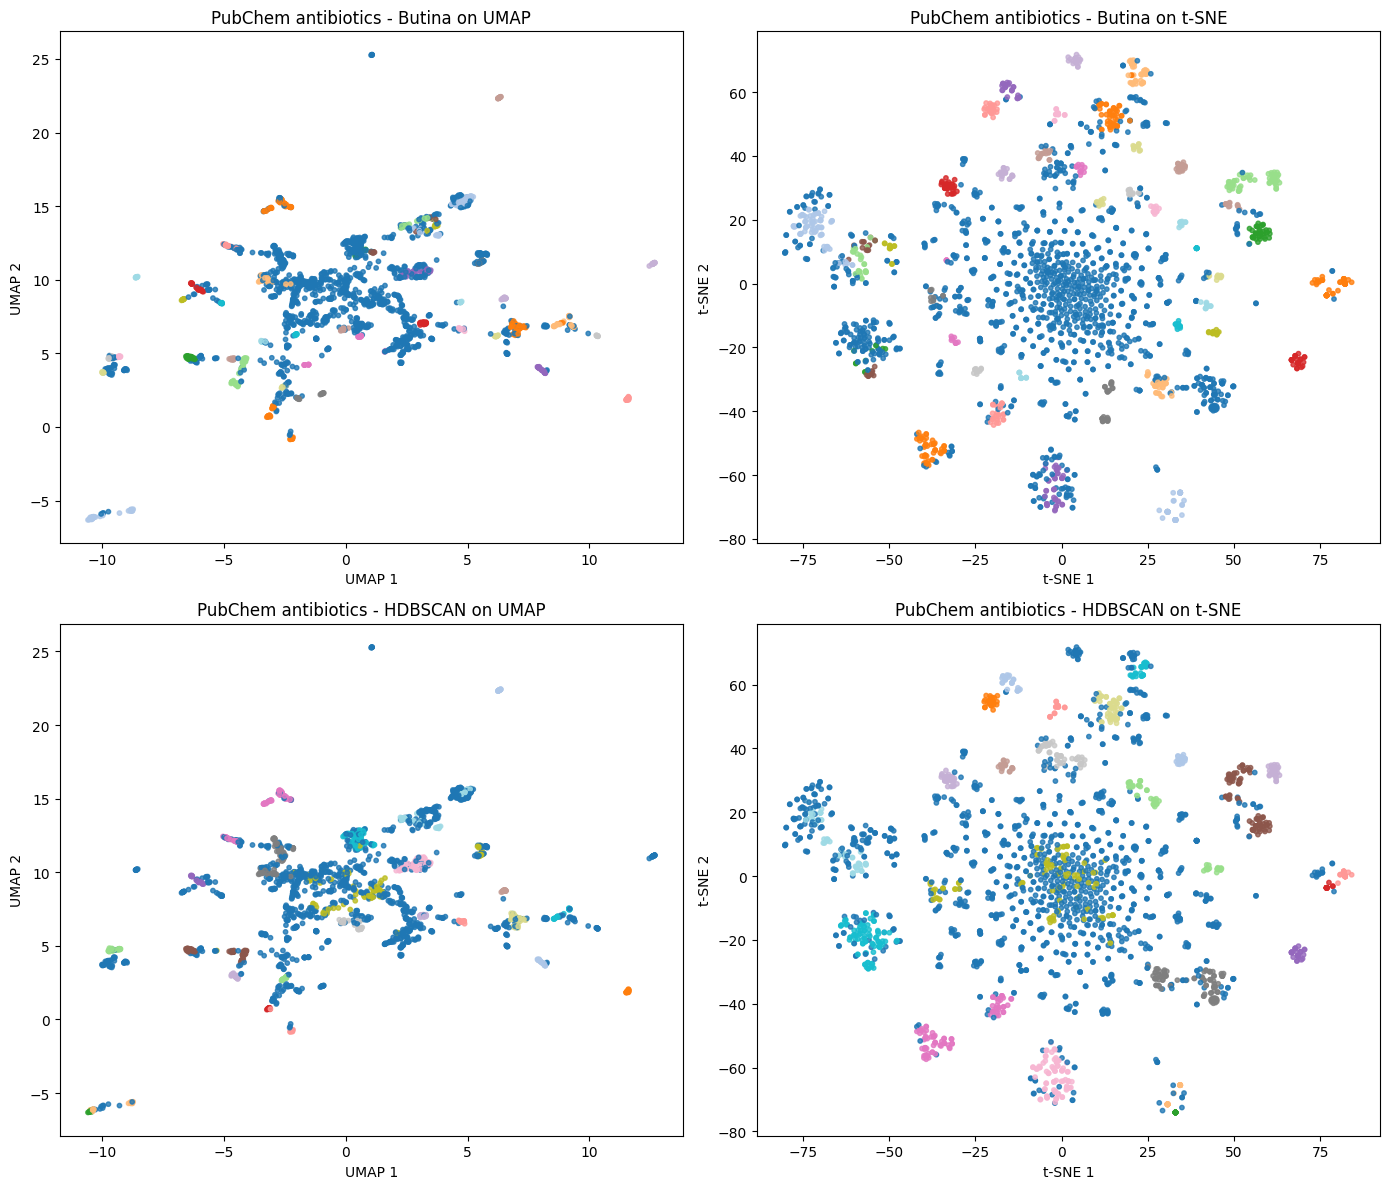

In [47]:
plot_clustering_visualization(
    dataset_name="PubChem antibiotics",
    umap_embedding=umap_pubchem,
    tsne_embedding=tsne_pubchem,
    butina_labels=butina_labels_pubchem,
    hdb_labels=hdb_labels_pubchem
)

In [48]:
def cluster_summary(labels):
    labels = np.array(labels)
    valid = labels[labels != -1]

    if len(valid) == 0:
        return pd.DataFrame(columns=["cluster", "size"])

    summary = pd.Series(valid).value_counts().sort_values(ascending=False)
    summary_df = summary.reset_index()
    summary_df.columns = ["cluster", "size"]
    return summary_df

print("ChEMBL Butina summary")
display(cluster_summary(butina_labels_chembl).head(10))

print("ChEMBL HDBSCAN summary")
display(cluster_summary(hdb_labels_chembl).head(10))

print("PubChem Butina summary")
display(cluster_summary(butina_labels_pubchem).head(10))

print("PubChem HDBSCAN summary")
display(cluster_summary(hdb_labels_pubchem).head(10))

ChEMBL Butina summary


,cluster,size
0,0,30
1,1,28
2,2,26
3,3,25
4,4,20
5,6,18
6,8,17
7,7,17
8,5,16
9,11,16


ChEMBL HDBSCAN summary


,cluster,size
0,1,8664
1,2,9
2,0,9


PubChem Butina summary


,cluster,size
0,0,79
1,1,74
2,2,72
3,3,57
4,4,53
5,5,50
6,6,49
7,10,36
8,8,36
9,11,33


PubChem HDBSCAN summary


,cluster,size
0,28,87
1,25,82
2,20,80
3,18,58
4,22,56
5,26,48
6,23,48
7,16,43
8,29,37
9,15,36


Visualise representative molecules of the three biggest clusters of both methods.

In [49]:
def get_cluster_members(df, labels, cluster_id):
    idx = np.where(np.array(labels) == cluster_id)[0]
    return df.iloc[idx].copy(), idx

def cluster_medoid(fp_list_cluster):
    n = len(fp_list_cluster)
    if n == 1:
        return 0

    avg_sims = []
    for i in range(n):
        sims = DataStructs.BulkTanimotoSimilarity(fp_list_cluster[i], fp_list_cluster)
        avg_sims.append(np.mean(sims))
    return int(np.argmax(avg_sims))

def representative_molecules(df, labels, top_n_clusters=3):
    summary = cluster_summary(labels)
    top_clusters = summary.head(top_n_clusters)["cluster"].tolist()

    reps = []
    for cid in top_clusters:
        cluster_df, idx = get_cluster_members(df, labels, cid)
        fp_list_cluster = cluster_df["fp"].tolist()
        medoid_local_idx = cluster_medoid(fp_list_cluster)
        rep_row = cluster_df.iloc[medoid_local_idx]
        reps.append({
            "cluster": cid,
            "size": len(cluster_df),
            "name": rep_row.get("name", ""),
            "smiles": rep_row["smiles_clean"],
            "mol": rep_row["mol"]
        })
    return pd.DataFrame(reps)

In [50]:
chembl_butina_reps = representative_molecules(chembl_fp, butina_labels_chembl, top_n_clusters=3)
chembl_hdb_reps = representative_molecules(chembl_fp, hdb_labels_chembl, top_n_clusters=3)

pubchem_butina_reps = representative_molecules(pubchem_fp, butina_labels_pubchem, top_n_clusters=3)
pubchem_hdb_reps = representative_molecules(pubchem_fp, hdb_labels_pubchem, top_n_clusters=3)

ChEMBL - Butina representatives


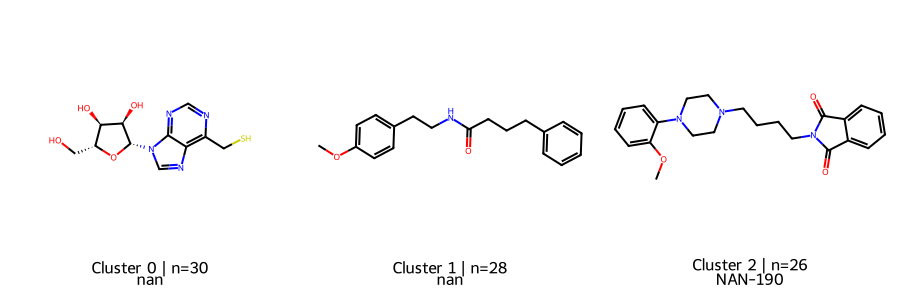

In [53]:
def draw_representatives(rep_df, title="Representative molecules"):
    mols = rep_df["mol"].tolist()
    legends = [
        f"Cluster {row['cluster']} | n={row['size']}\n{str(row['name'])[:30]}"
        for _, row in rep_df.iterrows()
    ]
    img = Draw.MolsToGridImage(
        mols,
        molsPerRow=3,
        subImgSize=(300, 300),
        legends=legends
    )
    print(title)
    return img

draw_representatives(chembl_butina_reps, "ChEMBL - Butina representatives")


ChEMBL - HDBSCAN representatives


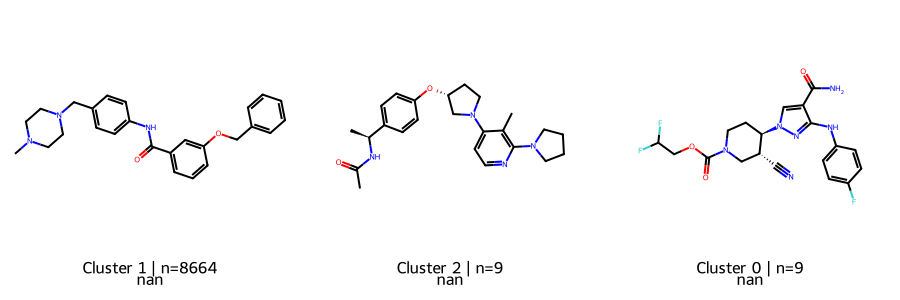

In [54]:
draw_representatives(chembl_hdb_reps, "ChEMBL - HDBSCAN representatives")

PubChem antibiotics - Butina representatives


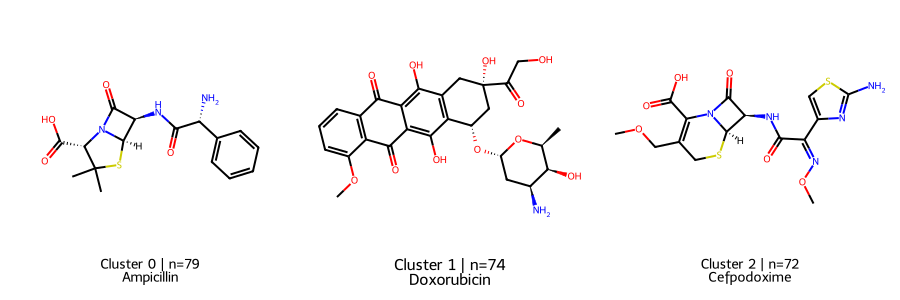

In [55]:
draw_representatives(pubchem_butina_reps, "PubChem antibiotics - Butina representatives")

PubChem antibiotics - HDBSCAN representatives


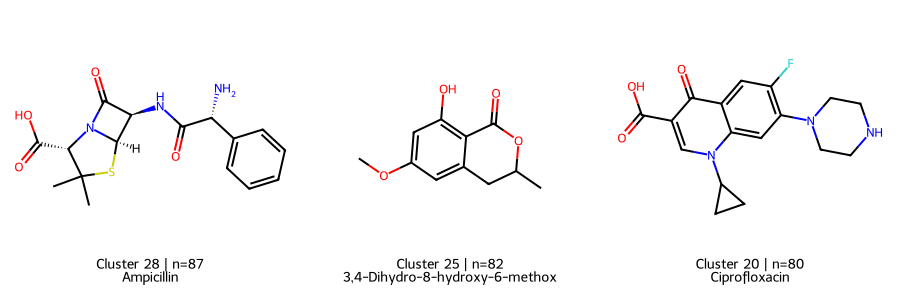

In [56]:
draw_representatives(pubchem_hdb_reps, "PubChem antibiotics - HDBSCAN representatives")

To find the best parameter

In [59]:
def evaluate_hdbscan_grid(X, min_cluster_sizes=[5, 10, 15], min_samples_list=[2, 5], metric="euclidean"):
    rows = []
    for mcs in min_cluster_sizes:
        for ms in min_samples_list:
            labels, model, stats = run_hdbscan(X, min_cluster_size=mcs, min_samples=ms, metric=metric)
            rows.append({
                "min_cluster_size": mcs,
                "min_samples": ms,
                "n_clusters": stats["n_clusters"],
                "n_noise": stats["n_noise"]
            })
    return pd.DataFrame(rows)

def evaluate_butina_grid(fp_list, cutoffs=[0.4, 0.5, 0.6], min_cluster_size=10):
    rows = []
    for cutoff in cutoffs:
        labels, clusters, filtered_clusters, stats = butina_clustering(fp_list, cutoff=cutoff, min_cluster_size=min_cluster_size)
        rows.append({
            "cutoff": cutoff,
            "n_total_clusters": stats["n_total_clusters"],
            "n_filtered_clusters": stats["n_filtered_clusters"],
            "mean_cluster_size": stats["mean_cluster_size"],
            "max_cluster_size": stats["max_cluster_size"],
            "n_noise": stats["n_noise"]
        })
    return pd.DataFrame(rows)

In [60]:
display(evaluate_butina_grid(chembl_fp_list, cutoffs=[0.4, 0.5, 0.6], min_cluster_size=10))
display(evaluate_hdbscan_grid(X_chembl, min_cluster_sizes=[5, 8, 10], min_samples_list=[2, 3, 5]))

display(evaluate_butina_grid(pubchem_fp_list, cutoffs=[0.4, 0.5, 0.6], min_cluster_size=10))
display(evaluate_hdbscan_grid(X_pubchem, min_cluster_sizes=[10, 15, 20], min_samples_list=[3, 5, 8]))

,cutoff,n_total_clusters,n_filtered_clusters,mean_cluster_size,max_cluster_size,n_noise
0,0.4,9518,0,0.000000,0,9993
1,0.5,8716,1,11.000000,11,9982
2,0.6,6824,31,14.483871,30,9544


,min_cluster_size,min_samples,n_clusters,n_noise
0,5,2,2,121
1,5,3,2,226
2,5,5,6,3261
3,8,2,3,1311
4,8,3,3,1726
5,8,5,2,930
6,10,2,4,5395
7,10,3,3,6059
8,10,5,0,9993


,cutoff,n_total_clusters,n_filtered_clusters,mean_cluster_size,max_cluster_size,n_noise
0,0.4,849,39,21.384615,64,1522
1,0.5,673,47,24.021277,79,1227
2,0.6,542,48,28.416667,125,992


,min_cluster_size,min_samples,n_clusters,n_noise
0,10,3,53,1092
1,10,5,50,1204
2,10,8,44,1251
3,15,3,30,1186
4,15,5,31,1312
5,15,8,26,1413
6,20,3,25,1227
7,20,5,24,1319
8,20,8,21,1380


## Discussion points
1) What are the characteristics of the chemical spaces described in the two dataset? What is the difference?
2) How do density-based clustering techniques compare to models based on similarity in light of the differences in the datasets?
3) What were the best model parameters for the clustering techniques (i.e. that delivered a meaningful result)
4) Comment on the different dimensionality reduction techniques (again in light of the different dataset characteristics)
5) What was the best / most meaningful combination of dimensionality reduction and clustering methods?
6) Comment on some cheminformatics modelling challenges you may have encountered (e.g. runtime, singleton clusters, paramtersensitivity). What could be done to work around a large number of clusters of small size?
7) On the antibiotics dataset, can you identify some known antibiotic classes / motives in your clusters?


1. I think in ChemBL its vast and diverse but in pubchem its more focused and less diverse 
   ChemBL dataset describes a medicinal chemistry space with many unrelated molecules.
   In pubchem the structers are mainly analogous series 

2. According to me similarity based clustering Butina is well suited for molecular fingerprints. 
   As it do clustering based on a pairwise fingerprint similarity so it will be good for close molecules.
   Density based clustering HDBSCAN depend on the local density . 
   So for ChemBL BUTINA will be a good choice bcz HDBSCAN Will produce too much noise 
   and for Pubchem HDBSCAN will be better .

3. For ChemBL :
    Butina ,cutoff 0.6
    HDBSCAN ,min_cluster_size = 8, min_samples = 5
  For Pubchem:
    Butina, cutoff 0.6
    HDBSCAN, min_cluster_size = 10, min_samples = 5  

4. UMAP is faster it preservs both local and global neighborhood structure.
 t-SNE is slower , it creates visually separated islands even when global distances are less meaningful.
 I think UMAP will be a better choice for this two datasets specially for the large ChemBL data.

5. UMAP+Butina for ChemBL
   UMAP+HDBSCAN for pubchem 

6. I encountered mainly these three-
  Run time ,
  Sensitiviy to cutoff , min_cluster_size, min_samples
  Class imbalance between large and small clusters
So we can slightly loosen the Butina strictness
and maybe we can use scaffold based preprocessing
and we should compare multiple parameter setting systematically.

7. Yeahh I know beta lactam and fluroquinolones